In [1]:
#Amy Independent Research, Fall 2024
import networkx as nx
import osmnx as ox
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
from folium.plugins import ScrollZoomToggler
import matplotlib.pyplot as plt
import shapely
from glob import glob
from datetime import timedelta
import osmnx.settings as settings
import osmnx.features as features

ox.__version__

settings.cache_folder = "/tmp/cache"

In [53]:
file_path = "/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/202101-citibike-tripdata_1.csv"

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

/var/folders/30/jfztb8191jzff8_xz9n0d59m0000gn/T/ipykernel_42436/4193616194.py:4: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [55]:
# Parse date columns explicitly
df['started_at'] = pd.to_datetime(df['started_at'], errors='coerce')
df['ended_at'] = pd.to_datetime(df['ended_at'], errors='coerce')

# Drop rows with invalid or missing dates
df = df.dropna(subset=['started_at', 'ended_at'])

# Ensure all dates are in 2021
df = df[df['started_at'].dt.year == 2021]

# Recalculate trip duration
df['trip_duration'] = (df['ended_at'] - df['started_at']).dt.total_seconds()
df['trip_duration_min'] = df['trip_duration'] / 60

# Extract temporal features
df['year'] = df['started_at'].dt.year
df['month'] = df['started_at'].dt.month
df['day_of_week'] = df['started_at'].dt.weekday  # 0=Monday, 6=Sunday

# Calculate week numbers
df['week_number'] = ((df['started_at'] - pd.Timestamp(f'{df["year"].iloc[0]}-01-01')).dt.days // 7 + 1)


In [56]:
# Define bounding boxes for each borough
borough_bounds = {
    'Manhattan': {'lat_min': 40.70, 'lat_max': 40.88, 'lng_min': -74.02, 'lng_max': -73.90},
    'Brooklyn': {'lat_min': 40.57, 'lat_max': 40.73, 'lng_min': -74.04, 'lng_max': -73.85},
    'Queens': {'lat_min': 40.54, 'lat_max': 40.80, 'lng_min': -73.95, 'lng_max': -73.70},
    'Bronx': {'lat_min': 40.79, 'lat_max': 40.91, 'lng_min': -73.93, 'lng_max': -73.80},
    'Staten Island': {'lat_min': 40.49, 'lat_max': 40.65, 'lng_min': -74.25, 'lng_max': -74.05}
}

def get_borough(lat, lng):
    for borough, bounds in borough_bounds.items():
        if bounds['lat_min'] <= lat <= bounds['lat_max'] and bounds['lng_min'] <= lng <= bounds['lng_max']:
            return borough
    return 'Other'

# Apply the get_borough function to determine the borough based on latitude and longitude
df['borough'] = df.apply(lambda row: get_borough(row['start_lat'], row['start_lng']), axis=1)

In [57]:
# Aggregate weekly data
weekly_aggregated = df.groupby(['year', 'week_number', 'month', 'borough']).agg(
    total_trips=('ride_id', 'count'),  # Total trips
    weekday_trips=('day_of_week', lambda x: (x < 5).sum()),  # Weekdays (Mon-Fri)
    weekend_trips=('day_of_week', lambda x: (x >= 5).sum()),  # Weekends (Sat-Sun)
    electric_bike_rides=('rideable_type', lambda x: (x == 'electric_bike').sum()),  # Electric bike trips
    classic_bike_rides=('rideable_type', lambda x: (x == 'classic_bike').sum()),  # Classic bike trips
    member_rides=('member_casual', lambda x: (x == 'member').sum()),  # Member trips
    casual_rides=('member_casual', lambda x: (x == 'casual').sum()),  # Casual trips
).reset_index()

# Calculate proportions and averages
weekly_aggregated['electric_bike_proportion'] = (
    weekly_aggregated['electric_bike_rides'] / weekly_aggregated['total_trips']
)
weekly_aggregated['classic_bike_proportion'] = (
    weekly_aggregated['classic_bike_rides'] / weekly_aggregated['total_trips']
)
weekly_aggregated['member_proportion'] = (
    weekly_aggregated['member_rides'] / weekly_aggregated['total_trips']
)
weekly_aggregated['casual_proportion'] = (
    weekly_aggregated['casual_rides'] / weekly_aggregated['total_trips']
)

# Average daily, weekday, and weekend trips
weekly_aggregated['avg_daily_trips'] = weekly_aggregated['total_trips'] / 7
weekly_aggregated['avg_weekday_trips'] = weekly_aggregated['weekday_trips'] / 5  # Average weekday trips
weekly_aggregated['avg_weekend_trips'] = weekly_aggregated['weekend_trips'] / 2  # Average weekend trips

In [58]:
print(weekly_aggregated)

    year  week_number  month    borough  total_trips  weekday_trips  \
0   2021            1      1      Bronx          422            314   
1   2021            1      1   Brooklyn        25750          18807   
2   2021            1      1  Manhattan       179583         135787   
3   2021            2      1      Bronx          437            348   
4   2021            2      1   Brooklyn        31789          22929   
5   2021            2      1  Manhattan       219448         164289   
6   2021            3      1      Bronx          402            264   
7   2021            3      1   Brooklyn        32967          22762   
8   2021            3      1  Manhattan       223232         160403   
9   2021            4      1      Bronx          259            184   
10  2021            4      1   Brooklyn        27578          20036   
11  2021            4      1  Manhattan       191420         144683   
12  2021            5      1      Bronx           96             23   
13  20

In [60]:
from glob import glob
import os

# Define the folder path
folder_path = "/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike"

# Generate all possible `.csv` files in the folder
all_files_in_folder = glob(os.path.join(folder_path, "*.csv"))
print(f"Total files in folder: {len(all_files_in_folder)}")

# Generate matched files with or without numbers
matched_files = []
for year in range(2021, 2025):  # From 2021 to 2024
    for month in range(1, 13):  # From January to December
        if year == 2024 and month > 11:  # Stop at November 2024
            break

        # Match files with or without numeric suffixes
        file_pattern_with_number = os.path.join(folder_path, f"{year}{month:02d}-citibike-tripdata_*.csv")
        file_pattern_without_number = os.path.join(folder_path, f"{year}{month:02d}-citibike-tripdata.csv")

        # Add matched files to the list
        matched_files.extend(glob(file_pattern_with_number))
        matched_files.extend(glob(file_pattern_without_number))

# Remove duplicates in case files match both patterns
matched_files = list(set(matched_files))
print(f"Matched files: {len(matched_files)}")

# Identify unmatched files
unmatched_files = set(all_files_in_folder) - set(matched_files)

# Print matched files for debugging
print("\nMatched Files:")
for file_path in sorted(matched_files):
    print(file_path)

# Print unmatched files for debugging
if unmatched_files:
    print("\nUnmatched Files:")
    for file_path in sorted(unmatched_files):
        print(file_path)
else:
    print("\nAll files matched successfully!")




Total files in folder: 143
Matched files: 143

Matched Files:
/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/202101-citibike-tripdata_1.csv
/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/202101-citibike-tripdata_2.csv
/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/202102-citibike-tripdata_1.csv
/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/202103-citibike-tripdata_1.csv
/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/202103-citibike-tripdata_2.csv
/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/202104-citibike-tripdata_1.csv
/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/202104-citibike-tripdata_2.csv
/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/202104-citibike-tripdata_3.csv
/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/202105-citibike-tripdata_1.csv
/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/202105-citibike-tripdata_2.csv
/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/202105-citib

In [81]:
from tqdm import tqdm
import pandas as pd
from glob import glob

# Define the function for borough assignment based on lat/lng
def get_borough(lat, lng):
    if 40.70 <= lat <= 40.88 and -74.02 <= lng <= -73.90:
        return 'Manhattan'
    elif 40.57 <= lat <= 40.73 and -74.04 <= lng <= -73.85:
        return 'Brooklyn'
    elif 40.54 <= lat <= 40.80 and -73.95 <= lng <= -73.70:
        return 'Queens'
    elif 40.79 <= lat <= 40.91 and -73.93 <= lng <= -73.80:
        return 'Bronx'
    elif 40.49 <= lat <= 40.65 and -74.25 <= lng <= -74.05:
        return 'Staten Island'
    else:
        return 'Other'

# Define the path to your files
path = '/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/*.csv'

# Initialize an empty DataFrame to store the aggregated results
final_weekly_data = pd.DataFrame()

# Get the list of files and sort them
all_files = sorted(glob(path))
print(f"Total files found: {len(all_files)}")

# Filter files explicitly starting from 2021
filtered_files = [file for file in all_files if '2021' in file or '2022' in file or '2023' in file or '2024' in file]
print(f"Filtered files (2021 onward): {len(filtered_files)}")

# Define the first week of 2021
first_week_2021 = pd.Timestamp('2021-01-04')  # ISO week starts on Monday

# Loop through each CSV file in the filtered list with progress tracking
for file in tqdm(filtered_files, desc="Processing Files"):
    try:
        tqdm.write(f"Processing file: {file}")  # Debug: Current file

        # Load the data
        df = pd.read_csv(file, low_memory=False)

        # Check for empty DataFrame
        if df.empty:
            tqdm.write(f"File {file} is empty. Skipping.")
            continue

        # Apply borough assignment
        df['borough'] = df.apply(lambda row: get_borough(row['start_lat'], row['start_lng']), axis=1)

        # Parse date columns explicitly
        df['started_at'] = pd.to_datetime(df['started_at'], errors='coerce')
        df['ended_at'] = pd.to_datetime(df['ended_at'], errors='coerce')

        # Drop rows with invalid or missing dates
        df = df.dropna(subset=['started_at', 'ended_at'])

        # Ensure year starts from 2021
        df = df[df['started_at'].dt.year >= 2021]

        # Calculate global week numbers starting from the first week of 2021
        df['week_number'] = ((df['started_at'] - first_week_2021).dt.days // 7 + 1)

        # Extract other temporal features
        df['year'] = df['started_at'].dt.year
        df['month'] = df['started_at'].dt.month
        df['day_of_week'] = df['started_at'].dt.weekday  # 0=Monday, 6=Sunday

        # Aggregate weekly data
        weekly_aggregated = df.groupby(['year', 'week_number', 'borough']).agg(
            total_trips=('ride_id', 'count'),
            weekday_trips=('ride_id', lambda x: x[df.loc[x.index, 'started_at'].dt.weekday < 5].count()),
            weekend_trips=('ride_id', lambda x: x[df.loc[x.index, 'started_at'].dt.weekday >= 5].count()),
            electric_bike_rides=('rideable_type', lambda x: (x == 'electric_bike').sum()),
            classic_bike_rides=('rideable_type', lambda x: (x == 'classic_bike').sum()),
            member_rides=('member_casual', lambda x: (x == 'member').sum()),
            casual_rides=('member_casual', lambda x: (x == 'casual').sum()),
        ).reset_index()

        # Add proportions and averages
        weekly_aggregated['electric_bike_proportion'] = weekly_aggregated['electric_bike_rides'] / weekly_aggregated['total_trips']
        weekly_aggregated['classic_bike_proportion'] = weekly_aggregated['classic_bike_rides'] / weekly_aggregated['total_trips']
        weekly_aggregated['member_proportion'] = weekly_aggregated['member_rides'] / weekly_aggregated['total_trips']
        weekly_aggregated['casual_proportion'] = weekly_aggregated['casual_rides'] / weekly_aggregated['total_trips']
        weekly_aggregated['avg_daily_trips'] = weekly_aggregated['total_trips'] / 7
        weekly_aggregated['avg_weekday_trips'] = weekly_aggregated['weekday_trips'] / 5
        weekly_aggregated['avg_weekend_trips'] = weekly_aggregated['weekend_trips'] / 2

        # Append to the final DataFrame
        final_weekly_data = pd.concat([final_weekly_data, weekly_aggregated], ignore_index=True)

        # Debug: Show the current combined data after processing
        tqdm.write(f"Combined Data (Rows: {final_weekly_data.shape[0]}):")
        tqdm.write(final_weekly_data.tail(5).to_string(index=False))  # Show last 5 rows

    except Exception as e:
        tqdm.write(f"Error processing file {file}: {e}")

# Reset the index if needed
final_weekly_data.reset_index(drop=True, inplace=True)

# Save the final DataFrame
final_weekly_data.to_csv('final_weekly_data.csv', index=False)
print("Final combined weekly data saved as final_weekly_data.csv")

# Display the final DataFrame
print(final_weekly_data)

Total files found: 143
Filtered files (2021 onward): 143


Processing Files:   0%|          | 0/143 [00:00<?, ?it/s]

Processing file: /Users/amyxqc/Desktop/amy_bikenycfall2024/Data/CitiBike/202101-citibike-tripdata_1.csv


/var/folders/30/jfztb8191jzff8_xz9n0d59m0000gn/T/ipykernel_42436/2304004437.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['started_at'] = pd.to_datetime(df['started_at'], errors='coerce')
/var/folders/30/jfztb8191jzff8_xz9n0d59m0000gn/T/ipykernel_42436/2304004437.py:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ended_at'] = pd.to_datetime(df['ended_at'], errors='coerce')
Processing Files:   1%|          | 1/143 [00:07<16:52,  7.13s/it]

Combined Data (Rows: 15):
 year  week_number   borough  total_trips  weekday_trips  weekend_trips  electric_bike_rides  classic_bike_rides  member_rides  casual_rides  electric_bike_proportion  classic_bike_proportion  member_proportion  casual_proportion  avg_daily_trips  avg_weekday_trips  avg_weekend_trips
 2021            3  Brooklyn        30743          23201           7542                14337               16406         25119          5624                  0.466350                 0.533650           0.817064           0.182936      4391.857143             4640.2             3771.0
 2021            3 Manhattan       209942         163205          46737                88418              121524        182221         27721                  0.421154                 0.578846           0.867959           0.132041     29991.714286            32641.0            23368.5
 2021            4     Bronx          234            161             73                  198                  36       

...

Processing Files:  99%|█████████▉| 142/143 [16:57<00:05,  5.93s/it]

Combined Data (Rows: 3625):
 year  week_number  borough  total_trips  weekday_trips  weekend_trips  electric_bike_rides  classic_bike_rides  member_rides  casual_rides  electric_bike_proportion  classic_bike_proportion  member_proportion  casual_proportion  avg_daily_trips  avg_weekday_trips  avg_weekend_trips
 2024          198    Other        21238          15244           5994                13209                8029         15796          5442                  0.621951                 0.378049           0.743761           0.256239      3034.000000             3048.8             2997.0
 2024          199 Brooklyn         3905           2929            976                 1735                2170          3222           683                  0.444302                 0.555698           0.825096           0.174904       557.857143              585.8              488.0
 2024          199    Other        22473          16726           5747                13315                9158         

Processing Files: 100%|██████████| 143/143 [16:57<00:00,  7.12s/it]

Combined Data (Rows: 3635):
 year  week_number  borough  total_trips  weekday_trips  weekend_trips  electric_bike_rides  classic_bike_rides  member_rides  casual_rides  electric_bike_proportion  classic_bike_proportion  member_proportion  casual_proportion  avg_daily_trips  avg_weekday_trips  avg_weekend_trips
 2024          202    Other        18613          13631           4982                12432                6181         14572          4041                  0.667920                 0.332080           0.782894           0.217106      2659.000000             2726.2             2491.0
 2024          203 Brooklyn         2580           1919            661                 1341                1239          2239           341                  0.519767                 0.480233           0.867829           0.132171       368.571429              383.8              330.5
 2024          203    Other        15298          11258           4040                10541                4757         

OSError: [Errno 30] Read-only file system: 'final_weekly_data.csv'

In [82]:
print(final_weekly_data)

      year  week_number    borough  total_trips  weekday_trips  weekend_trips  \
0     2021            0      Bronx          164             56            108   
1     2021            0   Brooklyn         9197           2254           6943   
2     2021            0  Manhattan        58588          14792          43796   
3     2021            1      Bronx          413            324             89   
4     2021            1   Brooklyn        29635          20775           8860   
...    ...          ...        ...          ...            ...            ...   
3630  2024          202      Other        18613          13631           4982   
3631  2024          203   Brooklyn         2580           1919            661   
3632  2024          203      Other        15298          11258           4040   
3633  2024          204   Brooklyn         1776           1590            186   
3634  2024          204      Other         9460           8271           1189   

      electric_bike_rides  

In [83]:
# Save as a CSV file
output_csv = '/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/Final/final_weekly_data_4.csv'
final_weekly_data.to_csv(output_csv, index=False)
print(f"Data saved as CSV to {output_csv}")

Data saved as CSV to /Users/amyxqc/Desktop/amy_bikenycfall2024/Data/Final/final_weekly_data_4.csv


# Initial Graphs

In [87]:
# Path to your saved CSV file
csv_file_path = '/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/Final/final_weekly_data.csv'  # Replace with your actual file path

# Read the CSV file into a DataFrame
final_weekly_data = pd.read_csv(csv_file_path)

# Display the first few rows of the DataFrame to verify
print(final_weekly_data.head())


   year  week_number    borough  total_trips  weekday_trips  weekend_trips  \
0  2021            1      Bronx          544            404            140   
1  2021            1   Brooklyn        27858          20350           7508   
2  2021            1  Manhattan       197947         149658          48289   
3  2021            2      Bronx          533            410            123   
4  2021            2   Brooklyn        34343          24741           9602   

   avg_daily_trips  avg_weekday_trips  avg_weekend_trips  
0        77.714286               80.8               70.0  
1      3979.714286             4070.0             3754.0  
2     28278.142857            29931.6            24144.5  
3        76.142857               82.0               61.5  
4      4906.142857             4948.2             4801.0  


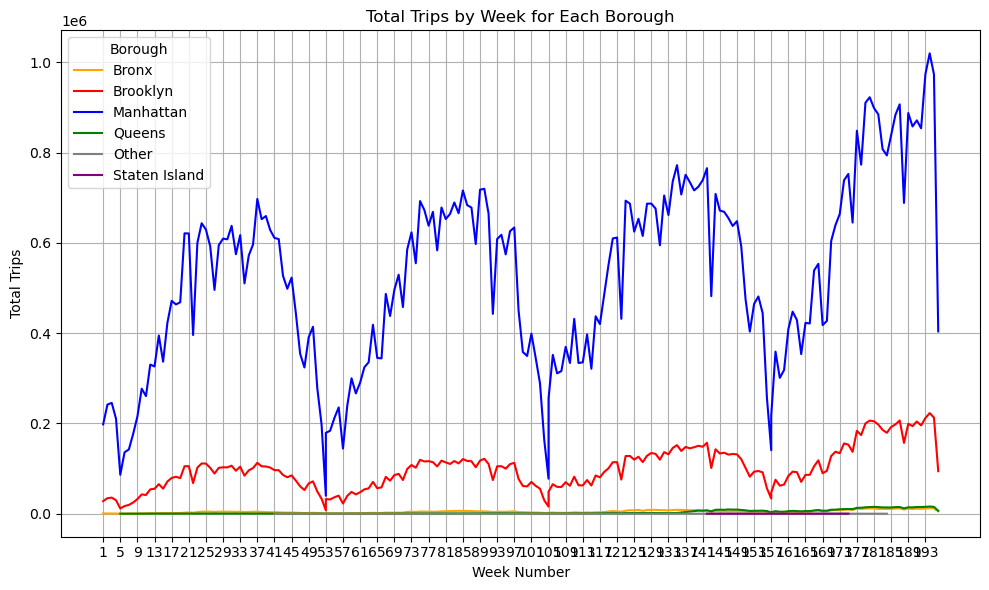

In [88]:
import matplotlib.pyplot as plt

# Assuming `final_weekly_data` is your DataFrame with columns: 'year', 'week_number', 'borough', 'total_trips'

# Create a figure and axis for the plot
plt.figure(figsize=(10, 6))

# Define a color map for different boroughs
colors = {
    'Manhattan': 'blue',
    'Brooklyn': 'red',
    'Queens': 'green',
    'Bronx': 'orange',
    'Staten Island': 'purple'
}

# Plot each borough's trips as a line
for borough in final_weekly_data['borough'].unique():
    subset = final_weekly_data[final_weekly_data['borough'] == borough]
    plt.plot(subset['week_number'], subset['total_trips'], 
             label=borough, color=colors.get(borough, 'gray'))

# Add labels and title
plt.title('Total Trips by Week for Each Borough')
plt.xlabel('Week Number')
plt.ylabel('Total Trips')
plt.xticks(range(1, final_weekly_data['week_number'].max() + 1, 4))  # Adjust x-ticks for better readability
plt.legend(title='Borough', loc='upper left')

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()